In [1]:
# mount drive to have access to data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [86]:
# import libraries
import numpy as np
import pandas as pd
from sklearn import linear_model
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Exercise 1

## Loading and Computing

### Exercise 1.1

In [45]:
# import data set data1.csv
data1 = pd.read_csv("data1.csv")

# separate X and y
X = data1.iloc[:, :-1]
y = data1.iloc[:, -1]

X = X.to_numpy()
y = y.to_numpy()


In [74]:
# Function to fit an OLS model using normal equations
def ordinary_OLS(X, y):
  theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

  # Compute training residuals
  y_hat = X @ theta_hat
  residuals = y - y_hat
  return np.array(residuals)


# Function to fit with sklearn method
def sklearn_OLS(X, y):
  reg = linear_model.LinearRegression()
  reg.fit(X, y)
  predictions = reg.predict(X)
  residuals = y - predictions
  # get the regression line obtained from scikitlearn on the full dataset
  beta_full = reg.coef_
  intercept_full = reg.intercept_
  return np.array(residuals), beta_full, intercept_full

In [76]:
# Fit functions in data
# assumed data is not centered, so it is important to add intercept column
X1 = np.c_[np.ones((X.shape[0], 1)), X]
residuals_OLS = ordinary_OLS(X1, y)
# sklearn will add this column automatically
residuals_sklearn, beta_full, intercept_full = sklearn_OLS(X, y)

In [48]:
# Check if implementations match
print(residuals_OLS)
print(residuals_sklearn)
 # our implementation matches sklearn, as it was expected

[ 0.90838225  3.79150177 -3.50267373 -0.91703604  0.40311604 -2.92982031
 -1.34471734 -2.07827825 -1.07355937  3.91207462  3.13237259 -2.93171865
  0.92206091 -1.34809115 -0.39800581 -0.32045321 -0.44681808  3.72138742
 -0.36945635 -1.22087311  2.76958723  1.55255096  1.77578453 -1.98760214
  0.69937574  0.57894115 -3.60109845 -0.71784765  2.54483993  0.21589769
  0.46950881  1.33816976 -3.51562712  1.65652651 -0.25154697  1.4326379
 -1.30259831  2.74265616  0.74704238  1.08445816 -1.66941145 -2.36015638
 -2.93621423 -3.35010635  2.12280967 -1.49136085 -0.84706203  2.35844005
  2.0320111 ]
[ 0.90838225  3.79150177 -3.50267373 -0.91703604  0.40311604 -2.92982031
 -1.34471734 -2.07827825 -1.07355937  3.91207462  3.13237259 -2.93171865
  0.92206091 -1.34809115 -0.39800581 -0.32045321 -0.44681808  3.72138742
 -0.36945635 -1.22087311  2.76958723  1.55255096  1.77578453 -1.98760214
  0.69937574  0.57894115 -3.60109845 -0.71784765  2.54483993  0.21589769
  0.46950881  1.33816976 -3.51562712  

### Exercise 1.2
We used B = 5000 bootstrap resamples to estimate the confidence interval for the slope. With n = 49 observations, the variability between resamples can be relatively high, so a large number of iterations helps stabilize the percentile estimates of the confidence interval's tails (2.5% and 97.5%). Empirical studies show that B ≥ 2000 generally yields accurate percentile-based CIs, and increasing to 5000 provides smoother convergence while remaining computationally feasible.

In [50]:
# check how many points i have on X
print(len(X))

49


In [53]:
# apply bootstrap and then use the coeficients obtained after B iterations to compute CI
B = 5000
n = len(X)

In [66]:
def bootstrap(X, y, B):
  n = len(X)
  boot_slopes = []
  boot_intercepts = []
  for b in range(B):
      # resample indices with replacement
      idx = np.random.randint(0, n, n)
      Xb, yb = X[idx], y[idx]

      # fit bootstrap model
      reg = linear_model.LinearRegression()
      reg.fit(Xb, yb)

      boot_slopes.append(reg.coef_[0])
      boot_intercepts.append(reg.intercept_)

  boot_slopes = np.array(boot_slopes)
  return boot_slopes, boot_intercepts

In [70]:
# compute intercept and slopes
boot_slopes, boot_intercepts = bootstrap(X, y, B)

In [71]:
# Compute CI - since the level of confidence interval was not specified, we will take 95% CI
lower, upper = np.percentile(boot_slopes, [2.5, 97.5])
print(f"Bootstrap 95% CI for slope: [{lower:.3f}, {upper:.3f}]")

Bootstrap 95% CI for slope: [1.670, 2.114]


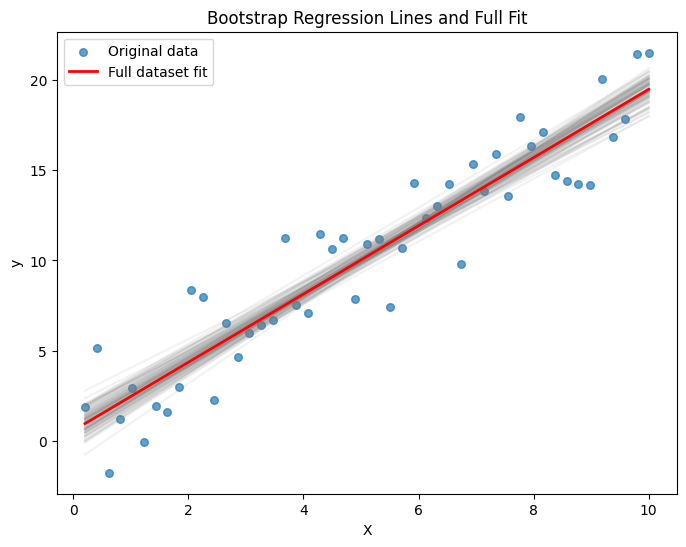

In [77]:
# plot results
plt.figure(figsize=(8,6))
plt.scatter(X, y, s=30, label="Original data", alpha=0.7)

# plot bootstrap regression lines
for i in range(100):  # plot subset for visibility
    plt.plot(X, boot_intercepts[i] + boot_slopes[i]*X, color='gray', alpha=0.1)

# plot final regression line
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = intercept_full + beta_full * x_line
plt.plot(x_line, y_line, color='red', lw=2, label='Full dataset fit')

plt.legend()
plt.title("Bootstrap Regression Lines and Full Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.show()


Using 5000 bootstrap resamples (pairs method), we obtained a 95% percentile confidence interval for the slope of the regression line: [1.670, 2.114].
This interval suggests that the true slope is likely close to 1.9, and the relatively narrow bounds indicate that the linear relationship between X and Y is well supported by the data.

## About the bootstrap samplees

### Exercise 1.4

By lefting βi out of the bootstrap sample Bi, since the model trained has never seen βi, we can use that βi as a validation set to estimate prediction error.By averaging the prediction errors computed on all out-of-bag samples accross the B bootstrap iterations we obtain an estimate of the model's generalization error. This is exactly the cross-validation process: separate data into folds, train in some of them and test in the others, repeat process and finally average the prediction metrics.

### Exercise 1.5

In each draw the probability that a specific observation does not appear is (n-1)/n, since there are n-1 possible choices for the other points. By repeating this process n times, the probability that the specific observation does not appear in any of the n draws becomes [(n-1)/n]^n. To compute the probability of the observation appearing, we take the complement: 1 - [(n-1)/n]^n. Then, as n becomes large this approximates 1 - e^-1, which is about 63%.

### Exercise 1.6

In [81]:
# verify empirically this result

# Simulating bootstrap
n = 49  # Size of the dataset
B = 5000  # Number of bootstrap samples
distinct_count = []

# Simulate B bootstrap samples
for _ in range(B):
    sample_idx = np.random.randint(0, n, n)  # Sample with replacement
    distinct_count.append(len(np.unique(sample_idx)))  # Count distinct observations

# Calculate the average number of distinct observations
avg_distinct = np.mean(distinct_count)
# this average is the result of p * n, where p is the probability of
# an observation appearing in a bootstrap sample
# calculate empirical probability of an observation appearing
empirical_prob = avg_distinct/n
print(f"Empirical probability of an observation appearing: {empirical_prob:.2f}")

# Theoretical prediction is about 63% of n
theoretical_distinct = 0.632
print(f"Theoretical number of distinct observations: {theoretical_distinct:.2f}")

Empirical probability of an observation appearing: 0.64
Theoretical number of distinct observations: 0.63


In [82]:
# report the number of distinct observations in each sample
print(distinct_count)

[34, 33, 30, 32, 30, 34, 32, 32, 31, 33, 30, 32, 33, 29, 34, 30, 36, 30, 28, 34, 32, 29, 28, 33, 35, 32, 30, 28, 30, 34, 33, 28, 33, 31, 32, 31, 32, 31, 29, 32, 33, 29, 30, 30, 32, 26, 32, 33, 31, 31, 33, 30, 33, 32, 32, 30, 26, 28, 30, 29, 31, 33, 31, 30, 33, 32, 31, 33, 31, 30, 32, 25, 30, 33, 29, 26, 31, 34, 33, 34, 30, 32, 31, 30, 32, 30, 30, 32, 34, 31, 27, 32, 29, 30, 31, 29, 32, 32, 31, 30, 33, 33, 29, 29, 29, 29, 33, 31, 32, 36, 31, 28, 29, 30, 28, 27, 34, 32, 30, 33, 31, 35, 31, 27, 28, 28, 33, 31, 32, 33, 28, 30, 30, 34, 31, 26, 34, 31, 37, 32, 32, 31, 30, 34, 29, 32, 33, 35, 30, 29, 34, 33, 32, 32, 30, 30, 34, 35, 29, 31, 31, 35, 29, 31, 30, 29, 32, 34, 32, 29, 29, 35, 31, 29, 31, 33, 30, 28, 29, 31, 30, 35, 29, 31, 33, 33, 30, 30, 34, 28, 33, 33, 33, 26, 31, 32, 32, 32, 32, 30, 30, 30, 29, 29, 30, 32, 32, 30, 31, 27, 34, 33, 29, 31, 33, 31, 34, 30, 32, 28, 30, 34, 35, 31, 32, 29, 33, 34, 32, 29, 33, 31, 33, 36, 30, 30, 29, 33, 29, 30, 30, 34, 33, 28, 29, 34, 32, 32, 31, 27,

In [83]:
# compare with expected number of distinct observations
print(f"Expected number of distinct observations: {0.63*49}")
print(f"Empirical probability of an observation appearing: {avg_distinct:.2f}")


Expected number of distinct observations: 30.87
Empirical probability of an observation appearing: 31.16


## Analysis of results

### Exercise 1.7

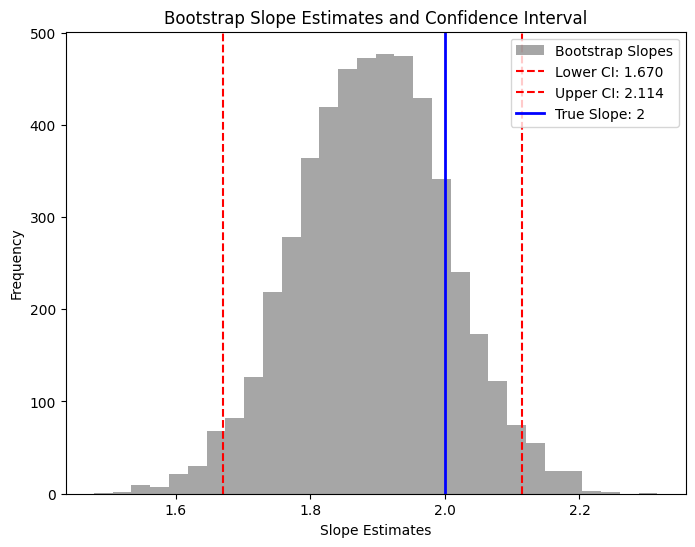

In [84]:
true_slope = 2  # The true slope coefficient θ₁*

# Plot histogram of bootstrap slopes
plt.figure(figsize=(8, 6))
plt.hist(boot_slopes, bins=30, color='gray', alpha=0.7, label="Bootstrap Slopes")

# Highlight the 95% confidence interval (bootstrap CI)
plt.axvline(x=lower, color='red', linestyle='--', label=f"Lower CI: {lower:.3f}")
plt.axvline(x=upper, color='red', linestyle='--', label=f"Upper CI: {upper:.3f}")

# Mark the true slope on the histogram
plt.axvline(x=true_slope, color='blue', linestyle='-', linewidth=2, label=f"True Slope: {true_slope}")

# Add labels and title
plt.xlabel("Slope Estimates")
plt.ylabel("Frequency")
plt.title("Bootstrap Slope Estimates and Confidence Interval")
plt.legend()

# Show the plot
plt.show()


It is possible to visualize that the true slope falls inside the CI, which validates our confidence interval as a good one.

### Exercise 1.8


In [87]:
# X and y are your original data
X = sm.add_constant(X)  # Add constant (intercept) to the dataset
model = sm.OLS(y, X)    # Fit OLS model
results = model.fit()

# Slope and standard error
beta_hat = results.params[1]  # The slope (beta_1)
se_beta_hat = results.bse[1]  # Standard error of the slope

# Asymptotic 95% CI
z_alpha = 1.96  # For 95% CI
lower_asymptotic = beta_hat - z_alpha * se_beta_hat
upper_asymptotic = beta_hat + z_alpha * se_beta_hat

print(f"Estimated slope: {beta_hat:.3f}")
print(f"Asymptotic 95% CI for slope: [{lower_asymptotic:.3f}, {upper_asymptotic:.3f}]")


Estimated slope: 1.893
Asymptotic 95% CI for slope: [1.688, 2.099]


The true slope coefficient falls inside the asymptotic CI. However, we observed that asymptotic CI is tighter because it is using observed standard error, while bootstrap CI captures more of the overall variation of data.

# Exercise 2

In [97]:
# load data2
data2 = pd.read_csv("data2.csv")

# separate X and y
X2 = data2.iloc[:, :-1]
y2 = data2.iloc[:, -1]


In [105]:
X2.describe()

,-0.20829831824686051,0.7934458349565143,-0.200864818629574,-0.005766182019787099,-0.336092071807896,0.037238120870671396,0.14831927942249726,-1.4236242711789568,-0.4115940511277518,0.54197455368346,...,0.4973545101559738,-0.21682492417211788,0.5526716958855378,0.4994002713926562,0.13466871868709143,-1.6397422127140873,-0.004639892186389855,-0.6350060681590168,-0.758948935801488,0.4883240688710019
count,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,...,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000
mean,-0.032499,-0.031255,-0.017958,0.038206,0.069970,-0.006451,-0.021534,0.002258,0.023321,-0.009888,...,0.046073,-0.014117,-0.004055,0.041605,0.022594,-0.055781,0.017696,0.000155,-0.050564,0.021149
std,0.642208,0.692635,0.686974,0.687942,0.667465,0.700711,0.687889,0.708571,0.714893,0.613839,...,0.674861,0.654501,0.677830,0.689604,0.711406,0.664889,0.659752,0.656171,0.669633,0.645867
min,-2.111656,-2.160524,-2.196784,-1.962590,-2.049115,-2.251311,-2.014032,-2.086034,-2.426860,-1.693861,...,-1.547124,-2.001422,-1.916204,-2.112235,-2.107448,-1.954555,-1.857772,-1.686031,-1.963597,-2.301028
25%,-0.475011,-0.519402,-0.465311,-0.455079,-0.382472,-0.472332,-0.452670,-0.462748,-0.469972,-0.408911,...,-0.442428,-0.477058,-0.509485,-0.395538,-0.446129,-0.496375,-0.453902,-0.466235,-0.544176,-0.375124
50%,-0.038660,-0.051131,-0.010290,0.021840,0.067723,-0.015477,0.005532,-0.040221,0.001358,0.022948,...,0.039410,0.004567,-0.016470,0.030706,0.037504,-0.028846,0.041502,-0.004022,-0.051046,0.022067
75%,0.412473,0.442882,0.405737,0.548705,0.506632,0.480484,0.469358,0.489011,0.505456,0.401272,...,0.447724,0.440359,0.467046,0.504754,0.487307,0.415197,0.462082,0.410202,0.387728,0.431613
max,1.962421,2.226542,1.914010,2.027069,2.519365,2.114968,2.061270,2.205315,2.328985,1.778059,...,1.793238,1.905152,1.883963,2.954763,2.341664,1.422870,2.319161,2.131425,2.630432,1.864192


### Exercise 2.9

In [102]:
selected_features = []
p_values = []

# Start with no features
remaining_features = list(X2.columns)

# Perform forward selection
while remaining_features:
    pvals = []  # p-values for this iteration
    for feature in remaining_features:
        # fit model with the selected feature plus one additional feature
        model = linear_model.LinearRegression()
        X2_temp = X2[selected_features + [feature]]
        model.fit(X2_temp, y2)

        # calculate p-values (using OLS assumption of Normal distribution for coefficients)
        # formula for standard error:
        predictions = model.predict(X2_temp)
        residuals = y2 - predictions
        residual_sum_of_squares = np.sum(residuals ** 2)
        standard_error = np.sqrt(residual_sum_of_squares / (len(y2) - len(X2_temp.columns)))

        # compute p-value for the selected feature
        # formula for p-value for coefficient j
        feature_index = X2_temp.columns.get_loc(feature)
        p_value = standard_error / np.std(X2_temp.iloc[:, feature_index])

        pvals.append((feature, p_value))

    # sort the features based on p-values
    pvals.sort(key=lambda x: x[1])
    selected_feature, min_pval = pvals[0]

    # add feature with the lowest p-value to the list of selected features
    selected_features.append(selected_feature)
    p_values.append(min_pval)

    # remove the selected feature from remaining features
    remaining_features.remove(selected_feature)

print(f"Selected features: {selected_features}")
print(f"p-values: {p_values}")


Selected features: ['296.0', '396.9', '65.2', '18.0', '4.98', '1.0', '0.00632', '2.31', '15.3', '4.09', '6.575', '-0.6037474404663932', '-0.02027671028632358', '-0.4115940511277518', '0.13466871868709143', '-0.9679938884448807', '0.2745587692310582', '-0.8884375052928367', '-1.4236242711789568', '1.1462185081749292', '0.3275223139263712', '-0.3917583877546104', '-0.8513739426400737', '-0.7218787010871944', '0.037238120870671396', '-0.5118933237710311', '0.5040792520706234', '-0.7712948515407424', '-1.3355313731695588', '0.4603517827106964', '0.7934458349565143', '-0.017683302661461637', '0.1999866654999127', '0.4994002713926562', '0.14831927942249726', '-1.04664258142777', '-0.005766182019787099', '-0.6461665245199872', '-0.200864818629574', '-0.020544843379260772', '0.9864131420030956', '0.3682811606953111', '0.7471442374521385', '0.4255156770750163', '-0.19109537466553825', '-0.13481507734713447', '0.4892820102695575', '0.40451447137305796', '0.391460204714064', '0.5526716958855378',

In [103]:
# create a data frame with feature and p-value
feature_pval_df = pd.DataFrame({'Feature': selected_features, 'p-value': p_values})
print(feature_pval_df)

                Feature    p-value
0                 296.0   0.048277
1                 396.9   0.088046
2                  65.2   0.281353
3                  18.0   0.333675
4                  4.98   0.842067
..                  ...        ...
95  -0.1778696441860089   7.675628
96  -0.3743403192955839   7.784144
97     0.54197455368346   7.802397
98                  0.0  18.783247
99                0.538  40.290815

[100 rows x 2 columns]


### Exercise 2.10

In forward selection, the hypothesis test determines whether a feature should be included in the model. In our case, we are testing the null hypothesis that the feature does not contribute to explaining the target varible y. This hypothesis is that for feature j the true coefficient of feature j is zero. The test statistic we use is based on the t-statistic with the formula of t = estimated coefficient/standard error. Since p-value is a monotone function of |tj|, choosing smallest p-value is equivalent to choosing the largest |tj|. P-value is the probability of observing the test statistic given H0 is true. If the p-value is small enough, we reject the null hypothesis.

### Exercise 2.11

In [108]:
def add_intercept(X):
    n = X.shape[0]
    return np.c_[np.ones((n, 1)), X]

def fit_beta_and_se(X, y):
    """
    Ordinary least squares: compute coefficients and standard errors.
    X must already include an intercept column.
    """
    XTX_inv = np.linalg.pinv(X.T @ X)
    beta = XTX_inv @ X.T @ y
    resid = y - X @ beta
    n, p = X.shape
    s2 = (resid @ resid) / (n - p)  # residual variance
    var_beta = s2 * XTX_inv
    se = np.sqrt(np.diag(var_beta))
    return beta, se

def normal_cdf(x):
    """Φ(x) using A&S 7.1.26 via an erf approximation (NumPy only)."""
    x = np.asarray(x, dtype=float)
    z = np.abs(x) / np.sqrt(2.0)

    # Abramowitz & Stegun coefficients
    p  = 0.3275911
    a1 = 0.254829592
    a2 = -0.284496736
    a3 = 1.421413741
    a4 = -1.453152027
    a5 = 1.061405429

    t = 1.0 / (1.0 + p * z)
    # erf(z) ≈ 1 - (((((a5 t + a4)t + a3)t + a2)t + a1)t) e^{-z^2})
    y = 1.0 - (((((a5*t + a4)*t + a3)*t + a2)*t + a1)*t) * np.exp(-z*z)
    erf_z = np.sign(x) * y  # restore sign

    return 0.5 * (1.0 + erf_z)

def p_from_t_normal(t_abs):
    """Two-sided p-value using the normal approximation (NumPy only)."""
    return 2.0 * (1.0 - normal_cdf(t_abs))

# --- Forward selection with stopping rule ---
def forward_select_with_stop(X_df, y, alpha=0.05, max_steps=None):
    cols_all = list(X_df.columns)
    remaining = cols_all.copy()
    selected = []
    selected_p = []
    step_stats = []
    step_best_idx = []

    k = 0
    while remaining and (max_steps is None or k < max_steps):
        stats_this_step = []
        cand_cols = []

        for c in remaining:
            X_sub = X_df[selected + [c]].to_numpy()
            X_sub = add_intercept(X_sub)
            beta, se = fit_beta_and_se(X_sub, y)

            # t-statistic for last coefficient (candidate)
            t_abs = np.abs(beta[-1] / se[-1])
            stats_this_step.append(t_abs)
            cand_cols.append(c)

        stats_this_step = np.array(stats_this_step)
        best_idx = int(np.argmax(stats_this_step))
        best_col = cand_cols[best_idx]
        best_t = stats_this_step[best_idx]
        best_p = p_from_t_normal(best_t)

        step_stats.append(stats_this_step)
        step_best_idx.append(best_idx)

        if best_p > alpha:
            break  # stopping criterion

        selected.append(best_col)
        selected_p.append(best_p)
        remaining.remove(best_col)
        k += 1

    return selected, selected_p, step_stats, step_best_idx


In [109]:
# Convert to numpy just once
y_vec = y2.to_numpy().astype(float)

selected, selected_p, step_stats, step_best_idx = forward_select_with_stop(X2, y_vec, alpha=0.05)

print("Selected variables (in order):", selected)
print("p-values:", [f"{p:.4g}" for p in selected_p])


Selected variables (in order): ['4.98', '6.575', '15.3', '4.09', '0.538', '0.0', '396.9', '18.0', '-0.8884375052928367', '-0.6344699260466847', '0.4603517827106964', '-0.21682492417211788', '1.0', '0.00632', '296.0', '1.0724230535371757', '-0.1225901642108334']
p-values: ['0', '0', '1.332e-15', '1.119e-05', '3.646e-08', '0.0002714', '0.000693', '0.004586', '0.02084', '0.02347', '0.02425', '0.03416', '0.03341', '0.001205', '0.001455', '0.02683', '0.02813']


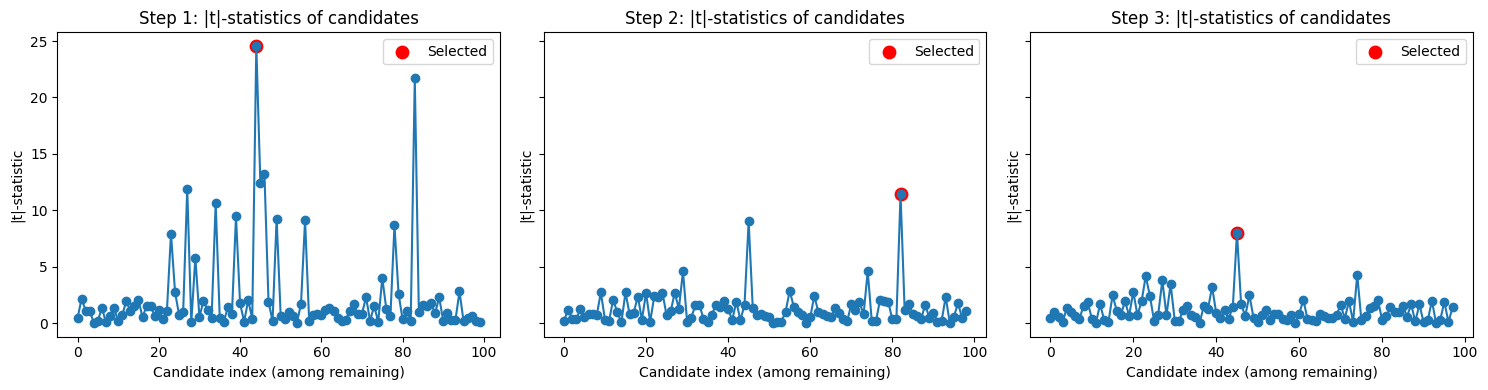

In [110]:
num_plots = min(3, len(step_stats))
fig, axes = plt.subplots(1, num_plots, figsize=(5*num_plots, 4), sharey=True)

for s in range(num_plots):
    ax = axes[s] if num_plots > 1 else axes
    stats = step_stats[s]
    ax.plot(range(len(stats)), stats, marker='o', linestyle='-')
    ax.scatter(step_best_idx[s], stats[step_best_idx[s]], s=80, color='red', label="Selected")
    ax.set_title(f"Step {s+1}: |t|-statistics of candidates")
    ax.set_xlabel("Candidate index (among remaining)")
    ax.set_ylabel("|t|-statistic")
    ax.legend()

plt.tight_layout()
plt.show()


Step 1: one candidate exhibits a much higher |t|-statistic than all others, indicating a strong relationship with
y; it is selected first.


---


Step 2: after controlling for the first variable, the |t|-values of the remaining predictors drop sharply—only one variable still shows notable significance and is selected.


---

Step 3: most remaining candidates have very low |t|-statistics, suggesting diminishing explanatory power.

### exercise 2.12

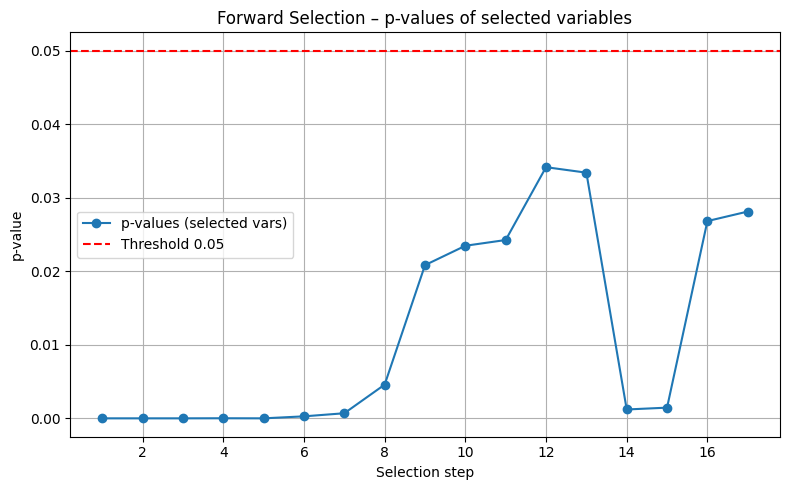

In [111]:
# Convert to NumPy array for easy slicing
p_values_array = np.array(selected_p)

# Limit to first 50 p-values
pv_to_plot = p_values_array[:50]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pv_to_plot) + 1), pv_to_plot, marker='o', label='p-values (selected vars)')
plt.axhline(0.05, color='red', linestyle='--', label='Threshold 0.05')

# Mark where the process stopped
stop_idx = np.argmax(pv_to_plot > 0.05)
if stop_idx > 0:
    plt.axvline(stop_idx, color='gray', linestyle=':', label=f'Stopping step = {stop_idx}')

# Labels and title
plt.xlabel("Selection step")
plt.ylabel("p-value")
plt.title("Forward Selection – p-values of selected variables")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The first few variables (steps 1–7) have extremely low p-values, well below the 0.05 threshold, meaning they are strongly associated with the target variable.
From around step 8 onward, the p-values start to rise, indicating that additional variables provide less independent information once the key predictors are already in the model. Although small fluctuations appear, all p-values remain below 0.05, so the stopping rule has not yet been triggered — the model could still accept more variables.

# Exercise 3

### Exercise 3.13

In [132]:
# load data3
data3 = pd.read_csv("data3.csv")

# separate X and y
X3 = data3.iloc[:, :-1]
y3 = data3.iloc[:, -1]


In [136]:
# Fit functions in data
X = np.asarray(X3, dtype=float)
y = np.asarray(y3, dtype=float).reshape(-1, 1)

residuals_OLS = ordinary_OLS(X, y)
residuals_sklearn, beta_full, intercept_full = sklearn_OLS(X3, y3)

In [137]:
# check if residuals match
print(np.allclose(residuals_OLS, residuals_sklearn, atol=1e-1))

False


In [ ]:
# the results do not match

### Exercise 3.14

##### ridge implementation

In [138]:
def ridge_numpy(X, y, alpha=1.0):
    """
    X: (n,p) features (no intercept column)
    y: (n,) or (n,1)
    alpha: ridge penalty λ (scikit-learn calls it alpha)
    returns: residuals, beta_full (p,), intercept (float)
    """
    X = np.asarray(X, float)
    y = np.asarray(y, float).reshape(-1, 1)
    n, p = X.shape

    # design with intercept
    X1 = np.c_[np.ones((n, 1)), X]                 # (n, p+1)

    # penalty matrix: 0 for intercept, λ on coefficients
    P = np.diag(np.r_[0.0, np.full(p, alpha)])     # (p+1, p+1)

    # closed form: (X^T X + P)^(-1) X^T y
    A = X1.T @ X1 + P
    beta_all = np.linalg.pinv(A) @ (X1.T @ y)      # (p+1, 1)

    intercept = float(beta_all[0, 0])
    beta = beta_all[1:, 0]
    yhat = X1 @ beta_all
    resid = (y - yhat).ravel()
    return resid, beta, intercept


In [139]:
res_ridge, beta_ridge, intercept_ridge = ridge_numpy(X, y, alpha=1)

##### moore penrose

In [140]:
def ols_pinv(X, y, add_intercept=True):
    """
    OLS using Moore–Penrose pseudoinverse.
    If add_intercept=True, a 1's column is added and *not* penalized.
    Returns: residuals (n,), coef (p,), intercept (float)
    """
    X = np.asarray(X, float)
    y = np.asarray(y, float).reshape(-1, 1)

    if add_intercept:
        X1 = np.c_[np.ones((X.shape[0], 1)), X]  # (n, p+1)
    else:
        X1 = X

    beta_all = np.linalg.pinv(X1) @ y           # SVD-based MP inverse
    yhat = X1 @ beta_all
    resid = (y - yhat).ravel()

    if add_intercept:
        intercept = float(beta_all[0, 0])
        coef = beta_all[1:, 0]
    else:
        intercept = 0.0
        coef = beta_all[:, 0]

    return resid, coef, intercept


In [141]:
res_moore, beta_moore, intercept_moore = ols_pinv(X, y)

In [143]:
#check which one is better

# r_skl: sklearn residuals (shape (n,) or (n,1))
# r_pinv: Moore–Penrose residuals
# r_ridge: Ridge residuals
r_skl = residuals_sklearn
r_pinv = res_moore
r_ridge = res_ridge


r_skl  = np.ravel(r_skl)
r_pinv = np.ravel(r_pinv)
r_ridge= np.ravel(r_ridge)

def compare(a, b):
    d = a - b
    return {
        "L2_norm"      : np.linalg.norm(d),            # Euclidean distance
        "L1_norm"      : np.sum(np.abs(d)),            # total abs difference
        "MAE"          : np.mean(np.abs(d)),           # mean abs error
        "RMSE"         : np.sqrt(np.mean(d**2)),       # root mean square error
        "MaxAbsDiff"   : np.max(np.abs(d)),            # worst-case diff
        "CosineSim"    : np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b)+1e-15)
    }

cmp_pinv  = compare(r_pinv, r_skl)
cmp_ridge = compare(r_ridge, r_skl)

print("PINV vs SKL:", cmp_pinv)
print("RIDGE vs SKL:", cmp_ridge)

# Quick verdicts:
print("Closer by L2:", "PINV" if cmp_pinv["L2_norm"] < cmp_ridge["L2_norm"] else "RIDGE")
print("Closer by MAE:", "PINV" if cmp_pinv["MAE"] < cmp_ridge["MAE"] else "RIDGE")


PINV vs SKL: {'L2_norm': np.float64(2.509398767818046e-14), 'L1_norm': np.float64(5.728750807065808e-14), 'MAE': np.float64(6.3652786745175644e-15), 'RMSE': np.float64(8.364662559393486e-15), 'MaxAbsDiff': np.float64(1.9539925233402755e-14), 'CosineSim': np.float64(9.712849895531004e-15)}
RIDGE vs SKL: {'L2_norm': np.float64(0.5138360286800304), 'L1_norm': np.float64(1.3322173310586818), 'MAE': np.float64(0.14802414789540908), 'RMSE': np.float64(0.1712786762266768), 'MaxAbsDiff': np.float64(0.29689983135385933), 'CosineSim': np.float64(-0.33042668557044746)}
Closer by L2: PINV
Closer by MAE: PINV


By our verification of metrics of distance and error, we conclude that  moore penrose method is better in this problem.

##